The data is provided by the medical segmentation decathlon challenge(http://medicaldecathlon.com/)

## Imports
**Task: Import the necessary libraries**

* Pathlib for easy path handling
* nibabel as the files are provided in the NIfTI format
* numpy for data saving and processing
* matplotlib for plotting
* cv2 for resizing

In [2]:
!python -m pip install matplotlib nibabel celluloid opencv-python

In [3]:

from pathlib import Path
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera
from tqdm.notebook import tqdm
import cv2


## Inspection:
Let's first inspect some sample data

**Task: Define the paths to images and labels**

In [4]:

root = Path("/scratch/ms4764/Task06_Lung/imagesTr/")
label = Path("/scratch/ms4764/Task06_Lung/labelsTr/")

**Task: Load a sample NIfTI and its corresponding label mask**<br />
Hint: You might want to define a helper function to make your life easier

In [5]:
def change_img_to_label_path(path):
    """
    Replaces imagesTr with labelsTr
    """
    parts = list(path.parts)  # get all directories whithin the path
    parts[parts.index("imagesTr")] = "labelsTr"  # Replace imagesTr with labelsTr
    return Path(*parts)  # Combine list back into a Path object


In [6]:
sample_path = list(root.glob("lung*"))[2]  # Choose a subject
sample_path_label = change_img_to_label_path(sample_path)

In [7]:
sample_path, sample_path_label

(PosixPath('/scratch/ms4764/Task06_Lung/imagesTr/lung_034.nii.gz'),
 PosixPath('/scratch/ms4764/Task06_Lung/labelsTr/lung_034.nii.gz'))

Load NIfTI and extract image data

In [8]:

data = nib.load(sample_path)
label = nib.load(sample_path_label)

ct = data.get_fdata()
mask = label.get_fdata()

**Task: Find out the orientation**

In [9]:


nib.aff2axcodes(data.affine)

('L', 'A', 'S')

## Preprocessing
1. Convert 3D medical scans into 2D training samples
2. Normalize CT intensities for better learning
3. Focus on lung region by removing irrelevant slices
4. Reduce class imbalance by dropping empty slices
5. Standardize size to 256×256

In [10]:
all_files = list(root.glob("lung_*"))  # Get all subjects

In [11]:
len(all_files)

63

In [12]:
import nibabel as nib
data = nib.load(sample_path)
label_data = nib.load(sample_path_label)

ct = data.get_fdata()
mask = label_data.get_fdata()

print("CT shape:", ct.shape)
print("Mask shape:", mask.shape)
print("Mask unique values:", np.unique(mask))
print("Orientation:", nib.aff2axcodes(data.affine))
print("Dimensions:", ct.ndim)

tumor_slices = []
for slice_index in range(mask.shape[2]):
    if np.any(mask[:, :, slice_index] > 0):
        tumor_slices.append(slice_index)

print("Number of tumor slices:", len(tumor_slices))
print("Tumor slice indices:", tumor_slices)

best_slice = max(tumor_slices, key=lambda i: np.sum(mask[:, :, i] > 0))
print("Best slice:", best_slice)

CT shape: (512, 512, 296)
Mask shape: (512, 512, 296)
Mask unique values: [0. 1.]
Orientation: ('L', 'A', 'S')
Dimensions: 3
Number of tumor slices: 27
Tumor slice indices: [160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186]
Best slice: 167


In [ ]:
# extracting 2D slices from a 3D CT volume

# slice_image = ct_data[:, :, i]
# mask_image = label_data[:, :, i]

In [64]:
from pathlib import Path
from tqdm import tqdm
import nibabel as nib
import numpy as np
import cv2
import random

save_root = Path("Task06_Lung/Preprocessed")

all_files = list(all_files)
random.seed(42)
random.shuffle(all_files)

total_subjects = len(all_files)

train_end = int(0.80 * total_subjects)
val_end = int(0.90 * total_subjects)

print("Total subjects:", total_subjects)
print("Train:", train_end)
print("Validation:", val_end - train_end)
print("Test:", total_subjects - val_end)

for counter, path_to_ct_data in enumerate(tqdm(all_files)):
    path_to_label = change_img_to_label_path(path_to_ct_data)

    ct_data = nib.load(path_to_ct_data).get_fdata()
    label_data = nib.load(path_to_label).get_fdata()

    ct_data = ct_data[:, :, 30:]
    label_data = label_data[:, :, 30:]

    # CT windowing and normalization
    ct_data = np.clip(ct_data, -1000, 400)
    ct_data = (ct_data + 1000) / 1400.0

    if counter < train_end:
        split = "train"
    elif counter < val_end:
        split = "val"
    else:
        split = "test"

    current_path = save_root / split / str(counter)

    slice_path = current_path / "data"
    mask_path = current_path / "masks"
    slice_path.mkdir(parents=True, exist_ok=True)
    mask_path.mkdir(parents=True, exist_ok=True)

    for i in range(ct_data.shape[-1]):
        slice_image = ct_data[:, :, i]
        mask_image = label_data[:, :, i]

        mask_image = (mask_image > 0).astype(np.uint8)

        has_tumor = np.any(mask_image > 0)
        if not has_tumor and random.random() > 0.2:
            continue

        slice_image = cv2.resize(slice_image, (256, 256))
        mask_image = cv2.resize(mask_image, (256, 256), interpolation=cv2.INTER_NEAREST)

        np.save(slice_path / f"{i}.npy", slice_image.astype(np.float32))
        np.save(mask_path / f"{i}.npy", mask_image.astype(np.uint8))

Total subjects: 63
Train: 50
Validation: 6
Test: 7


100%|███████████████████████████████████████████████████████████████████████████████| 63/63 [01:57<00:00,  1.86s/it]


In [7]:
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import Dataset

class LungSegmentationDataset(Dataset):
    def __init__(self, split_root):
        self.samples = []
        split_root = Path(split_root)

        patient_folders = sorted(
            [folder for folder in split_root.iterdir() if folder.is_dir()],
            key=lambda x: int(x.name)
        )

        for patient_folder in patient_folders:
            data_folder = patient_folder / "data"
            mask_folder = patient_folder / "masks"

            if not data_folder.exists() or not mask_folder.exists():
                continue

            slice_files = sorted(data_folder.glob("*.npy"), key=lambda x: int(x.stem))

            for slice_file in slice_files:
                mask_file = mask_folder / slice_file.name
                if mask_file.exists():
                    self.samples.append((slice_file, mask_file))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        slice_file, mask_file = self.samples[index]

        image = np.load(slice_file).astype(np.float32)
        mask = np.load(mask_file).astype(np.float32)

        image = np.expand_dims(image, axis=0)   # (1, H, W)
        mask = np.expand_dims(mask, axis=0)     # (1, H, W)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [9]:
from pathlib import Path
from torch.utils.data import DataLoader

data_root = Path("Task06_Lung/Preprocessed")

train_dataset = LungSegmentationDataset(data_root / "train")
val_dataset = LungSegmentationDataset(data_root / "val")
test_dataset = LungSegmentationDataset(data_root / "test")

print("Train slices:", len(train_dataset))
print("Validation slices:", len(val_dataset))
print("Test slices:", len(test_dataset))

batch_size = 8
num_workers = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

Train slices: 3551
Validation slices: 422
Test slices: 524


In [3]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        skip1 = self.down1(x)
        x = self.pool1(skip1)

        skip2 = self.down2(x)
        x = self.pool2(skip2)

        skip3 = self.down3(x)
        x = self.pool3(skip3)

        x = self.bridge(x)

        x = self.up3(x)
        x = torch.cat([x, skip3], dim=1)
        x = self.conv3(x)

        x = self.up2(x)
        x = torch.cat([x, skip2], dim=1)
        x = self.conv2(x)

        x = self.up1(x)
        x = torch.cat([x, skip1], dim=1)
        x = self.conv1(x)

        return self.final(x)

In [16]:
import torch
import torch.nn as nn

class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets, smooth=1e-6):
        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        probs = probs.contiguous()
        targets = targets.contiguous()

        intersection = (probs * targets).sum(dim=(1, 2, 3))
        union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        dice = (2.0 * intersection + smooth) / (union + smooth)
        dice_loss = 1.0 - dice.mean()

        return bce_loss + dice_loss


def compute_batch_metrics(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.contiguous()
    targets = targets.contiguous()

    tp = (preds * targets).sum(dim=(1, 2, 3))
    fp = (preds * (1 - targets)).sum(dim=(1, 2, 3))
    fn = ((1 - preds) * targets).sum(dim=(1, 2, 3))

    dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    iou = (tp + smooth) / (tp + fp + fn + smooth)
    precision = (tp + smooth) / (tp + fp + smooth)
    recall = (tp + smooth) / (tp + fn + smooth)

    return (
        dice.mean().item(),
        iou.mean().item(),
        precision.mean().item(),
        recall.mean().item()
    )

In [18]:
import torch

def train_one_epoch(model, dataloader, optimizer, loss_function, device):
    model.train()
    total_loss = 0.0

    for images, masks in dataloader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_function(logits, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate_model(model, dataloader, loss_function, device, threshold=0.5):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_precision = 0.0
    total_recall = 0.0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = loss_function(logits, masks)

            dice, iou, precision, recall = compute_batch_metrics(
                logits, masks, threshold=threshold
            )

            total_loss += loss.item()
            total_dice += dice
            total_iou += iou
            total_precision += precision
            total_recall += recall

    num_batches = len(dataloader)

    return {
        "loss": total_loss / num_batches,
        "dice": total_dice / num_batches,
        "iou": total_iou / num_batches,
        "precision": total_precision / num_batches,
        "recall": total_recall / num_batches
    }

In [19]:
import torch
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

unet_model = UNet().to(device)
loss_function = DiceBCELoss()
optimizer = torch.optim.Adam(unet_model.parameters(), lr=1e-4)

num_epochs = 100

best_val_dice = 0.0
best_model_weights = copy.deepcopy(unet_model.state_dict())

for epoch in range(num_epochs):
    train_loss = train_one_epoch(unet_model, train_loader, optimizer, loss_function, device)
    val_results = evaluate_model(unet_model, val_loader, loss_function, device, threshold=0.5)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_results['loss']:.4f} | "
        f"Val Dice: {val_results['dice']:.4f} | "
        f"Val IoU: {val_results['iou']:.4f} | "
        f"Val Precision: {val_results['precision']:.4f} | "
        f"Val Recall: {val_results['recall']:.4f}"
    )

    if val_results["dice"] > best_val_dice:
        best_val_dice = val_results["dice"]
        best_model_weights = copy.deepcopy(unet_model.state_dict())
        torch.save(best_model_weights, "best_unet_lung_segmentation.pth")
        print(f"Saved new best model with Val Dice: {best_val_dice:.4f}")

Using device: cuda
Epoch 1/100 | Train Loss: 1.2280 | Val Loss: 1.1360 | Val Dice: 0.5173 | Val IoU: 0.5173 | Val Precision: 1.0000 | Val Recall: 0.5173
Saved new best model with Val Dice: 0.5173
Epoch 2/100 | Train Loss: 1.0895 | Val Loss: 1.0617 | Val Dice: 0.5234 | Val IoU: 0.5158 | Val Precision: 0.9662 | Val Recall: 0.5366
Saved new best model with Val Dice: 0.5234
Epoch 3/100 | Train Loss: 1.0142 | Val Loss: 0.9649 | Val Dice: 0.5859 | Val IoU: 0.5420 | Val Precision: 0.7563 | Val Recall: 0.6979
Saved new best model with Val Dice: 0.5859
Epoch 4/100 | Train Loss: 0.9559 | Val Loss: 0.9103 | Val Dice: 0.5959 | Val IoU: 0.5575 | Val Precision: 0.8503 | Val Recall: 0.6730
Saved new best model with Val Dice: 0.5959
Epoch 5/100 | Train Loss: 0.8925 | Val Loss: 0.9151 | Val Dice: 0.5111 | Val IoU: 0.4789 | Val Precision: 0.7431 | Val Recall: 0.6630
Epoch 6/100 | Train Loss: 0.8343 | Val Loss: 0.8618 | Val Dice: 0.6153 | Val IoU: 0.5780 | Val Precision: 0.8847 | Val Recall: 0.6674
Saved

In [20]:

state_dict = torch.load("best_unet_lung_segmentation.pth", map_location=device, weights_only=True)
unet_model.load_state_dict(state_dict)
unet_model.to(device)

test_results = evaluate_model(unet_model, test_loader, loss_function, device, threshold=0.5)

print("\nFinal Test Results")
print(f"Test Dice:      {test_results['dice']:.6f}")
print(f"Test IoU:       {test_results['iou']:.6f}")
print(f"Test Precision: {test_results['precision']:.6f}")
print(f"Test Recall:    {test_results['recall']:.6f}")


Final Test Results
Test Dice:      0.760104
Test IoU:       0.744283
Test Precision: 0.975829
Test Recall:    0.758547


In [21]:
import math
import torch
import torch.nn as nn
import torchvision


class DoubleConv(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, input_tensor):
        return self.layers(input_tensor)


class DecoderBlock(nn.Module):
    def __init__(self, input_channels, skip_channels, output_channels):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.convolution_block = DoubleConv(input_channels + skip_channels, output_channels)

    def forward(self, input_tensor, skip_tensor=None):
        upsampled_tensor = self.upsample(input_tensor)

        if skip_tensor is not None:
            merged_tensor = torch.cat([upsampled_tensor, skip_tensor], dim=1)
        else:
            merged_tensor = upsampled_tensor

        output_tensor = self.convolution_block(merged_tensor)
        return output_tensor


class PatchEmbedding(nn.Module):
    def __init__(self, input_channels, embedding_dimension, patch_size, feature_map_size):
        super().__init__()

        self.patch_size = patch_size
        self.feature_map_size = feature_map_size
        self.number_of_patches = (feature_map_size // patch_size) * (feature_map_size // patch_size)

        self.projection = nn.Conv2d(
            in_channels=input_channels,
            out_channels=embedding_dimension,
            kernel_size=patch_size,
            stride=patch_size
        )

        self.position_embedding = nn.Parameter(
            torch.zeros(1, self.number_of_patches, embedding_dimension)
        )

    def forward(self, feature_map):
        token_tensor = self.projection(feature_map)     # [B, D, H_p, W_p]
        token_tensor = token_tensor.flatten(2)          # [B, D, N]
        token_tensor = token_tensor.transpose(1, 2)     # [B, N, D]
        token_tensor = token_tensor + self.position_embedding
        return token_tensor


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embedding_dimension, number_of_heads, mlp_dimension, dropout_rate=0.1):
        super().__init__()

        self.normalization_1 = nn.LayerNorm(embedding_dimension)
        self.attention = nn.MultiheadAttention(
            embed_dim=embedding_dimension,
            num_heads=number_of_heads,
            dropout=dropout_rate,
            batch_first=True
        )

        self.normalization_2 = nn.LayerNorm(embedding_dimension)
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dimension, mlp_dimension),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(mlp_dimension, embedding_dimension),
            nn.Dropout(dropout_rate)
        )

    def forward(self, token_tensor):
        normalized_tensor = self.normalization_1(token_tensor)
        attention_output, _ = self.attention(
            normalized_tensor,
            normalized_tensor,
            normalized_tensor
        )
        token_tensor = token_tensor + attention_output

        normalized_tensor = self.normalization_2(token_tensor)
        mlp_output = self.mlp(normalized_tensor)
        token_tensor = token_tensor + mlp_output

        return token_tensor


class TransformerEncoder(nn.Module):
    def __init__(self, embedding_dimension, number_of_heads, mlp_dimension, number_of_layers, dropout_rate=0.1):
        super().__init__()

        self.layers = nn.ModuleList([
            TransformerEncoderBlock(
                embedding_dimension=embedding_dimension,
                number_of_heads=number_of_heads,
                mlp_dimension=mlp_dimension,
                dropout_rate=dropout_rate
            )
            for _ in range(number_of_layers)
        ])

        self.final_normalization = nn.LayerNorm(embedding_dimension)

    def forward(self, token_tensor):
        for transformer_layer in self.layers:
            token_tensor = transformer_layer(token_tensor)

        token_tensor = self.final_normalization(token_tensor)
        return token_tensor




class ResNetEncoder(nn.Module):
    def __init__(self, input_channels=1, pretrained=True):
        super().__init__()

        if pretrained:
            backbone = torchvision.models.resnet34(
                weights=torchvision.models.ResNet34_Weights.DEFAULT
            )
        else:
            backbone = torchvision.models.resnet34(weights=None)

        
        if input_channels != 3:
            original_conv = backbone.conv1

            new_conv = nn.Conv2d(
                input_channels,
                original_conv.out_channels,
                kernel_size=original_conv.kernel_size,
                stride=original_conv.stride,
                padding=original_conv.padding,
                bias=False
            )

            if pretrained and input_channels == 1:
                with torch.no_grad():
    
                    new_conv.weight[:] = original_conv.weight.mean(dim=1, keepdim=True)

            backbone.conv1 = new_conv
        

        self.initial = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu
        )

        self.maxpool = backbone.maxpool
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

    def forward(self, x):
        skip1 = self.initial(x)
        x = self.maxpool(skip1)

        skip2 = self.layer1(x)
        skip3 = self.layer2(skip2)
        skip4 = self.layer3(skip3)
        bottleneck = self.layer4(skip4)

        return skip1, skip2, skip3, skip4, bottleneck




class TransUNet(nn.Module):
    def __init__(
        self,
        input_channels=1,
        output_classes=1,
        image_size=256,
        patch_size=1,
        embedding_dimension=256,
        number_of_heads=4,
        mlp_dimension=512,
        number_of_transformer_layers=4,
        pretrained_backbone=False
    ):
        super().__init__()

        self.image_size = image_size

        self.encoder = ResNetEncoder(
            input_channels=input_channels,
            pretrained=pretrained_backbone
        )

        bottleneck_feature_map_size = image_size // 32

        self.patch_embedding = PatchEmbedding(
            input_channels=512,
            embedding_dimension=embedding_dimension,
            patch_size=patch_size,
            feature_map_size=bottleneck_feature_map_size
        )

        self.transformer_encoder = TransformerEncoder(
            embedding_dimension=embedding_dimension,
            number_of_heads=number_of_heads,
            mlp_dimension=mlp_dimension,
            number_of_layers=number_of_transformer_layers,
            dropout_rate=0.1
        )

        self.transformer_to_feature_map = nn.Sequential(
            nn.Conv2d(embedding_dimension, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        self.decoder_block_1 = DecoderBlock(512, 256, 256)  # /32 -> /16
        self.decoder_block_2 = DecoderBlock(256, 128, 128)  # /16 -> /8
        self.decoder_block_3 = DecoderBlock(128, 64, 64)    # /8 -> /4
        self.decoder_block_4 = DecoderBlock(64, 64, 64)     # /4 -> /2
        self.decoder_block_5 = DecoderBlock(64, 0, 32)      # /2 -> full

        self.segmentation_head = nn.Conv2d(32, output_classes, kernel_size=1)

    def forward(self, input_image):
        skip_feature_map_1, skip_feature_map_2, skip_feature_map_3, skip_feature_map_4, bottleneck_feature_map = self.encoder(input_image)

        token_tensor = self.patch_embedding(bottleneck_feature_map)
        token_tensor = self.transformer_encoder(token_tensor)

        batch_size, patch_count, embedding_dimension = token_tensor.shape
        feature_map_height = int(math.sqrt(patch_count))
        feature_map_width = int(math.sqrt(patch_count))

        transformed_feature_map = token_tensor.transpose(1, 2).contiguous().view(
            batch_size,
            embedding_dimension,
            feature_map_height,
            feature_map_width
        )

        transformed_feature_map = self.transformer_to_feature_map(transformed_feature_map)

        decoded_feature_map_1 = self.decoder_block_1(transformed_feature_map, skip_feature_map_4)
        decoded_feature_map_2 = self.decoder_block_2(decoded_feature_map_1, skip_feature_map_3)
        decoded_feature_map_3 = self.decoder_block_3(decoded_feature_map_2, skip_feature_map_2)
        decoded_feature_map_4 = self.decoder_block_4(decoded_feature_map_3, skip_feature_map_1)
        decoded_feature_map_5 = self.decoder_block_5(decoded_feature_map_4, None)

        segmentation_logits = self.segmentation_head(decoded_feature_map_5)
        return segmentation_logits

In [22]:
import torch
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# model = UNet().to(device)


model = TransUNet(
    input_channels=1,
    output_classes=1,
    image_size=256,
    patch_size=1,
    embedding_dimension=256,
    number_of_heads=4,
    mlp_dimension=512,
    number_of_transformer_layers=4,
    pretrained_backbone=True
).to(device)


loss_function = DiceBCELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 100

best_val_dice = 0.0
best_model_weights = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_function, device)
    val_results = evaluate_model(model, val_loader, loss_function, device, threshold=0.5)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_results['loss']:.4f} | "
        f"Val Dice: {val_results['dice']:.4f} | "
        f"Val IoU: {val_results['iou']:.4f} | "
        f"Val Precision: {val_results['precision']:.4f} | "
        f"Val Recall: {val_results['recall']:.4f}"
    )

    if val_results["dice"] > best_val_dice:
        best_val_dice = val_results["dice"]
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(best_model_weights, "best_transunet_lung_segmentation.pth")
        print(f"Saved new best model with Val Dice: {best_val_dice:.4f}")

Using device: cuda
Epoch 1/100 | Train Loss: 1.3980 | Val Loss: 1.2955 | Val Dice: 0.4395 | Val IoU: 0.4395 | Val Precision: 0.9222 | Val Recall: 0.5173
Saved new best model with Val Dice: 0.4395
Epoch 2/100 | Train Loss: 1.2481 | Val Loss: 1.1950 | Val Dice: 0.4259 | Val IoU: 0.3909 | Val Precision: 0.5413 | Val Recall: 0.7013
Epoch 3/100 | Train Loss: 1.1615 | Val Loss: 1.1240 | Val Dice: 0.6093 | Val IoU: 0.5749 | Val Precision: 0.8535 | Val Recall: 0.6720
Saved new best model with Val Dice: 0.6093
Epoch 4/100 | Train Loss: 1.0964 | Val Loss: 1.0820 | Val Dice: 0.5825 | Val IoU: 0.5590 | Val Precision: 0.9059 | Val Recall: 0.6160
Epoch 5/100 | Train Loss: 1.0335 | Val Loss: 1.0288 | Val Dice: 0.5745 | Val IoU: 0.5509 | Val Precision: 0.8986 | Val Recall: 0.6147
Epoch 6/100 | Train Loss: 0.9695 | Val Loss: 0.9779 | Val Dice: 0.5280 | Val IoU: 0.4984 | Val Precision: 0.7754 | Val Recall: 0.6358
Epoch 7/100 | Train Loss: 0.9086 | Val Loss: 0.9708 | Val Dice: 0.4300 | Val IoU: 0.4029 | 

In [23]:
state_dict = torch.load("best_transunet_lung_segmentation.pth", map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.to(device)

test_results = evaluate_model(model, test_loader, loss_function, device, threshold=0.5)

print("\nFinal Test Results of TransUNET")

print(f"Test Dice:      {test_results['dice']:.6f}")
print(f"Test IoU:       {test_results['iou']:.6f}")
print(f"Test Precision: {test_results['precision']:.6f}")
print(f"Test Recall:    {test_results['recall']:.6f}")


Final Test Results of TransUNET
Test Dice:      0.767758
Test IoU:       0.748622
Test Precision: 0.920209
Test Recall:    0.791402


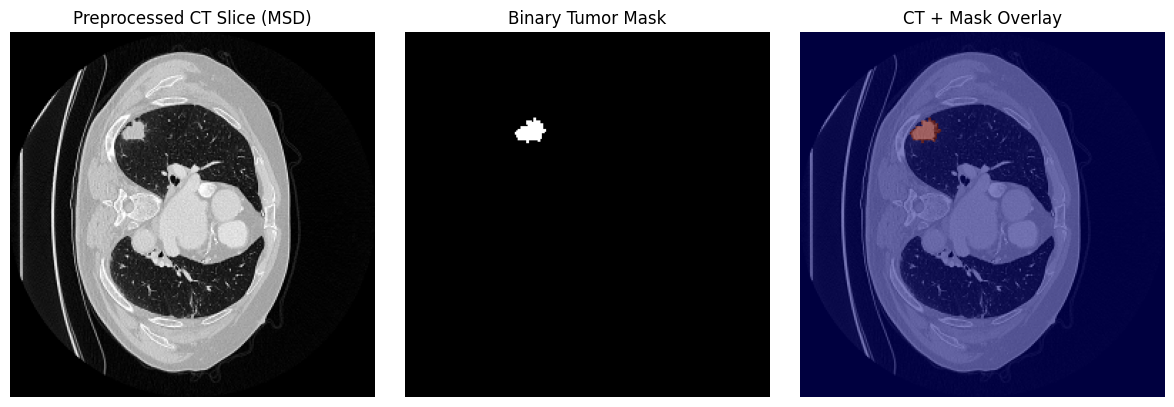

In [14]:
import nibabel as nib
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Reload original 3D CT and 3D mask
ct = nib.load(sample_path).get_fdata()
mask = nib.load(sample_path_label).get_fdata()


# extracting one 2D slice from a 3D scan

slice_index = 167

image = ct[:, :, slice_index]
mask_slice = mask[:, :, slice_index]

# preprocessing
image = np.clip(image, -1000, 400)
image = (image + 1000) / 1400.0

mask_slice = (mask_slice > 0).astype(np.uint8)

image = cv2.resize(image, (256, 256))
mask_slice = cv2.resize(mask_slice, (256, 256), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Preprocessed CT Slice (MSD)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_slice, cmap="gray")
plt.title("Binary Tumor Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image, cmap="gray")
plt.imshow(mask_slice, alpha=0.5, cmap="jet")
plt.title("CT + Mask Overlay")
plt.axis("off")

plt.tight_layout()
plt.savefig("msd_preprocessed_slice_167.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# CT + Mask Overlay: A visualization where the tumor mask is superimposed on the CT image to highlight tumor location.

In [ ]:
# Diffusion Model

# all-slice validation 

In [11]:
import copy
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# Diffusion schedule

def linear_beta_schedule(total_timesteps):
    beta_start = 1e-4
    beta_end = 1e-2
    return torch.linspace(beta_start, beta_end, total_timesteps, dtype=torch.float32)


timesteps = 1000

betas = linear_beta_schedule(timesteps).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)


def add_noise_to_mask(clean_mask, t):
    noise = torch.randn_like(clean_mask)

    sqrt_alpha_t = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_t = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    noisy_mask = sqrt_alpha_t * clean_mask + sqrt_one_minus_alpha_t * noise
    return noisy_mask, noise


Using device: cuda


In [4]:

# Model

class DoubleConv(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class TimeEmbedding(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(1, embedding_dim),
            nn.ReLU(inplace=True),
            nn.Linear(embedding_dim, embedding_dim)
        )

    def forward(self, t):
        t = t.float() / (timesteps - 1)
        t = t.unsqueeze(1)
        return self.mlp(t)


class DiffusionUNet(nn.Module):
    def __init__(self, time_embedding_dim=64):
        super().__init__()

        self.time_embedding = TimeEmbedding(time_embedding_dim)

        self.down1 = DoubleConv(2, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

        self.time_to_64 = nn.Linear(time_embedding_dim, 64)
        self.time_to_128 = nn.Linear(time_embedding_dim, 128)
        self.time_to_256 = nn.Linear(time_embedding_dim, 256)
        self.time_to_512 = nn.Linear(time_embedding_dim, 512)

    def add_time(self, feature_map, time_layer, time_embedding):
        batch_size, channels, _, _ = feature_map.shape
        time_features = time_layer(time_embedding).view(batch_size, channels, 1, 1)
        return feature_map + time_features

    def forward(self, image, noisy_mask, t):
        x = torch.cat([image, noisy_mask], dim=1)
        time_embedding = self.time_embedding(t)

        skip1 = self.down1(x)
        skip1 = self.add_time(skip1, self.time_to_64, time_embedding)
        x = self.pool1(skip1)

        skip2 = self.down2(x)
        skip2 = self.add_time(skip2, self.time_to_128, time_embedding)
        x = self.pool2(skip2)

        skip3 = self.down3(x)
        skip3 = self.add_time(skip3, self.time_to_256, time_embedding)
        x = self.pool3(skip3)

        x = self.bridge(x)
        x = self.add_time(x, self.time_to_512, time_embedding)

        x = self.up3(x)
        x = torch.cat([x, skip3], dim=1)
        x = self.conv3(x)

        x = self.up2(x)
        x = torch.cat([x, skip2], dim=1)
        x = self.conv2(x)

        x = self.up1(x)
        x = torch.cat([x, skip1], dim=1)
        x = self.conv1(x)

        predicted_noise = self.final(x)
        return predicted_noise


In [13]:

# reconstructing clean mask

def reconstruct_clean_mask(noisy_mask, predicted_noise, t):
    sqrt_alpha_t = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_t = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)

    predicted_clean_mask = (
        noisy_mask - sqrt_one_minus_alpha_t * predicted_noise
    ) / (sqrt_alpha_t + 1e-8)

    return predicted_clean_mask



# Metrics

def compute_segmentation_metrics_from_logits(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    tp = (preds * targets).sum(dim=(1, 2, 3))
    fp = (preds * (1 - targets)).sum(dim=(1, 2, 3))
    fn = ((1 - preds) * targets).sum(dim=(1, 2, 3))

    dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    iou = (tp + smooth) / (tp + fp + fn + smooth)
    precision = (tp + smooth) / (tp + fp + smooth)
    recall = (tp + smooth) / (tp + fn + smooth)

    return dice, iou, precision, recall




def dice_bce_loss_from_logits(logits, targets, smooth=1e-6):
    bce = nn.BCEWithLogitsLoss()(logits, targets)

    probs = torch.sigmoid(logits)
    intersection = (probs * targets).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice_loss = 1.0 - ((2.0 * intersection + smooth) / (union + smooth)).mean()

    return bce + dice_loss

In [14]:

# Training and validation with combined loss

def train_diffusion_one_epoch(model, dataloader, optimizer, segmentation_loss_weight=0.5):
    model.train()

    total_loss = 0.0
    total_noise_loss = 0.0
    total_segmentation_loss = 0.0

    mse_loss_function = nn.MSELoss()
   

    for images, masks in dataloader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        batch_size = images.shape[0]
        t = torch.randint(0, timesteps, (batch_size,), device=device).long()

        noisy_masks, true_noise = add_noise_to_mask(masks, t)

        optimizer.zero_grad()

        predicted_noise = model(images, noisy_masks, t)
        predicted_clean_mask_logits = reconstruct_clean_mask(noisy_masks, predicted_noise, t)
        predicted_clean_mask_logits = torch.clamp(predicted_clean_mask_logits, -6.0, 6.0)
        noise_loss = mse_loss_function(predicted_noise, true_noise)
       
        segmentation_loss = dice_bce_loss_from_logits(predicted_clean_mask_logits, masks)

        total_batch_loss = noise_loss + segmentation_loss_weight * segmentation_loss

        total_batch_loss.backward()
        optimizer.step()

        total_loss += total_batch_loss.item()
        total_noise_loss += noise_loss.item()
        total_segmentation_loss += segmentation_loss.item()

    number_of_batches = len(dataloader)

    return {
        "total_loss": total_loss / number_of_batches,
        "noise_loss": total_noise_loss / number_of_batches,
        "segmentation_loss": total_segmentation_loss / number_of_batches
    }


def validate_diffusion(model, dataloader, threshold=0.5, segmentation_loss_weight=0.5):
    model.eval()

    total_loss = 0.0
    total_noise_loss = 0.0
    total_segmentation_loss = 0.0

    all_dice = []
    all_iou = []
    all_precision = []
    all_recall = []

    mse_loss_function = nn.MSELoss()
    # bce_loss_function = nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            batch_size = images.shape[0]
            t = torch.randint(0, timesteps, (batch_size,), device=device).long()

            noisy_masks, true_noise = add_noise_to_mask(masks, t)

            predicted_noise = model(images, noisy_masks, t)
            predicted_clean_mask_logits = reconstruct_clean_mask(noisy_masks, predicted_noise, t)
            predicted_clean_mask_logits = torch.clamp(predicted_clean_mask_logits, -6.0, 6.0)

            noise_loss = mse_loss_function(predicted_noise, true_noise)
            segmentation_loss = dice_bce_loss_from_logits(predicted_clean_mask_logits, masks)
            total_batch_loss = noise_loss + segmentation_loss_weight * segmentation_loss

            total_loss += total_batch_loss.item()
            total_noise_loss += noise_loss.item()
            total_segmentation_loss += segmentation_loss.item()

            dice, iou, precision, recall = compute_segmentation_metrics_from_logits(
                predicted_clean_mask_logits,
                masks,
                threshold=threshold
            )

            all_dice.extend(dice.cpu().numpy())
            all_iou.extend(iou.cpu().numpy())
            all_precision.extend(precision.cpu().numpy())
            all_recall.extend(recall.cpu().numpy())

    number_of_batches = len(dataloader)

    return {
        "total_loss": total_loss / number_of_batches,
        "noise_loss": total_noise_loss / number_of_batches,
        "segmentation_loss": total_segmentation_loss / number_of_batches,
        "dice": float(np.mean(all_dice)) if len(all_dice) > 0 else 0.0,
        "iou": float(np.mean(all_iou)) if len(all_iou) > 0 else 0.0,
        "precision": float(np.mean(all_precision)) if len(all_precision) > 0 else 0.0,
        "recall": float(np.mean(all_recall)) if len(all_recall) > 0 else 0.0,
        "evaluated_slices": len(all_dice)
    }




def evaluate_diffusion_reconstruction_all_slices(model, dataloader, threshold=0.5):
    model.eval()

    all_dice = []
    all_iou = []
    all_precision = []
    all_recall = []

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            batch_size = images.shape[0]

            t = torch.full(
                (batch_size,),
                timesteps // 2,
                device=device,
                dtype=torch.long
            )

            noisy_masks, _ = add_noise_to_mask(masks, t)
            predicted_noise = model(images, noisy_masks, t)

            predicted_clean_mask_logits = reconstruct_clean_mask(
                noisy_masks,
                predicted_noise,
                t
            )

            dice, iou, precision, recall = compute_segmentation_metrics_from_logits(
                predicted_clean_mask_logits,
                masks,
                threshold=threshold
            )

            all_dice.extend(dice.cpu().numpy())
            all_iou.extend(iou.cpu().numpy())
            all_precision.extend(precision.cpu().numpy())
            all_recall.extend(recall.cpu().numpy())

    return {
        "dice": float(np.mean(all_dice)) if len(all_dice) > 0 else 0.0,
        "iou": float(np.mean(all_iou)) if len(all_iou) > 0 else 0.0,
        "precision": float(np.mean(all_precision)) if len(all_precision) > 0 else 0.0,
        "recall": float(np.mean(all_recall)) if len(all_recall) > 0 else 0.0,
        "evaluated_slices": len(all_dice)
    }


In [28]:

#  Train

diffusion_model = DiffusionUNet().to(device)
optimizer = torch.optim.Adam(diffusion_model.parameters(), lr=5e-5)

num_epochs = 100
segmentation_loss_weight = 5.0
validation_threshold = 0.5

best_val_dice = 0.0
best_model_weights = copy.deepcopy(diffusion_model.state_dict())

for epoch in range(num_epochs):
    train_results = train_diffusion_one_epoch(
        diffusion_model,
        train_loader,
        optimizer,
        segmentation_loss_weight=segmentation_loss_weight
    )

    val_results = validate_diffusion(
        diffusion_model,
        val_loader,
        threshold=validation_threshold,
        segmentation_loss_weight=segmentation_loss_weight
    )

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Total Loss: {train_results['total_loss']:.6f} | "
        f"Train Noise Loss: {train_results['noise_loss']:.6f} | "
        f"Train Seg Loss: {train_results['segmentation_loss']:.6f} | "
        f"Val Total Loss: {val_results['total_loss']:.6f} | "
        f"Val Dice: {val_results['dice']:.6f} | "
        f"Val IoU: {val_results['iou']:.6f} | "
        f"Val Precision: {val_results['precision']:.6f} | "
        f"Val Recall: {val_results['recall']:.6f}"
      
    )

    if val_results["dice"] > best_val_dice:
        best_val_dice = val_results["dice"]
        best_model_weights = copy.deepcopy(diffusion_model.state_dict())
        torch.save(best_model_weights, "best_diffusion_unet_combined_loss.pth")
        print(f"Saved new best model with Val Dice: {best_val_dice:.6f}")




Epoch 1/100 | Train Total Loss: 7.474952 | Train Noise Loss: 0.385431 | Train Seg Loss: 1.417904 | Val Total Loss: 6.874331 | Val Dice: 0.181974 | Val IoU: 0.136092 | Val Precision: 0.165968 | Val Recall: 0.815815
Saved new best model with Val Dice: 0.181974
Epoch 2/100 | Train Total Loss: 6.938358 | Train Noise Loss: 0.413679 | Train Seg Loss: 1.304936 | Val Total Loss: 6.896325 | Val Dice: 0.162695 | Val IoU: 0.117249 | Val Precision: 0.120075 | Val Recall: 0.859992
Epoch 3/100 | Train Total Loss: 6.906521 | Train Noise Loss: 0.442911 | Train Seg Loss: 1.292722 | Val Total Loss: 6.780388 | Val Dice: 0.241815 | Val IoU: 0.200290 | Val Precision: 0.275391 | Val Recall: 0.799869
Saved new best model with Val Dice: 0.241815
Epoch 4/100 | Train Total Loss: 6.841522 | Train Noise Loss: 0.456435 | Train Seg Loss: 1.277017 | Val Total Loss: 6.582959 | Val Dice: 0.346711 | Val IoU: 0.305463 | Val Precision: 0.413005 | Val Recall: 0.812817
Saved new best model with Val Dice: 0.346711
Epoch 5/1

In [29]:

# Test
state_dict = torch.load( "best_diffusion_unet_combined_loss.pth", map_location=device, weights_only=True)
diffusion_model.load_state_dict(state_dict)
diffusion_model.to(device)

test_results = evaluate_diffusion_reconstruction_all_slices(diffusion_model,test_loader,threshold=0.5)

print(f"\nFinal Reconstruction-Based Test Results of Diffusion model: ")
print(f"Test Dice:      {test_results['dice']:.6f}")
print(f"Test IoU:       {test_results['iou']:.6f}")
print(f"Test Precision: {test_results['precision']:.6f}")
print(f"Test Recall:    {test_results['recall']:.6f}")


Final Reconstruction-Based Test Results of Diffusion model: 
Test Dice:      0.867465
Test IoU:       0.835341
Test Precision: 0.900656
Test Recall:    0.924448


In [57]:
class DoubleConv(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

    

for name, param in DiffusionUNet().named_parameters():
   
    if "bias" in name:
        print(name)

time_embedding.mlp.0.bias
time_embedding.mlp.2.bias
down1.block.1.bias
down1.block.4.bias
down2.block.1.bias
down2.block.4.bias
down3.block.1.bias
down3.block.4.bias
bridge.block.1.bias
bridge.block.4.bias
up3.bias
conv3.block.1.bias
conv3.block.4.bias
up2.bias
conv2.block.1.bias
conv2.block.4.bias
up1.bias
conv1.block.1.bias
conv1.block.4.bias
final.bias
time_to_64.bias
time_to_128.bias
time_to_256.bias
time_to_512.bias


Diffusion model loaded successfully
Top 5 indices: [320, 326, 322, 328, 323]


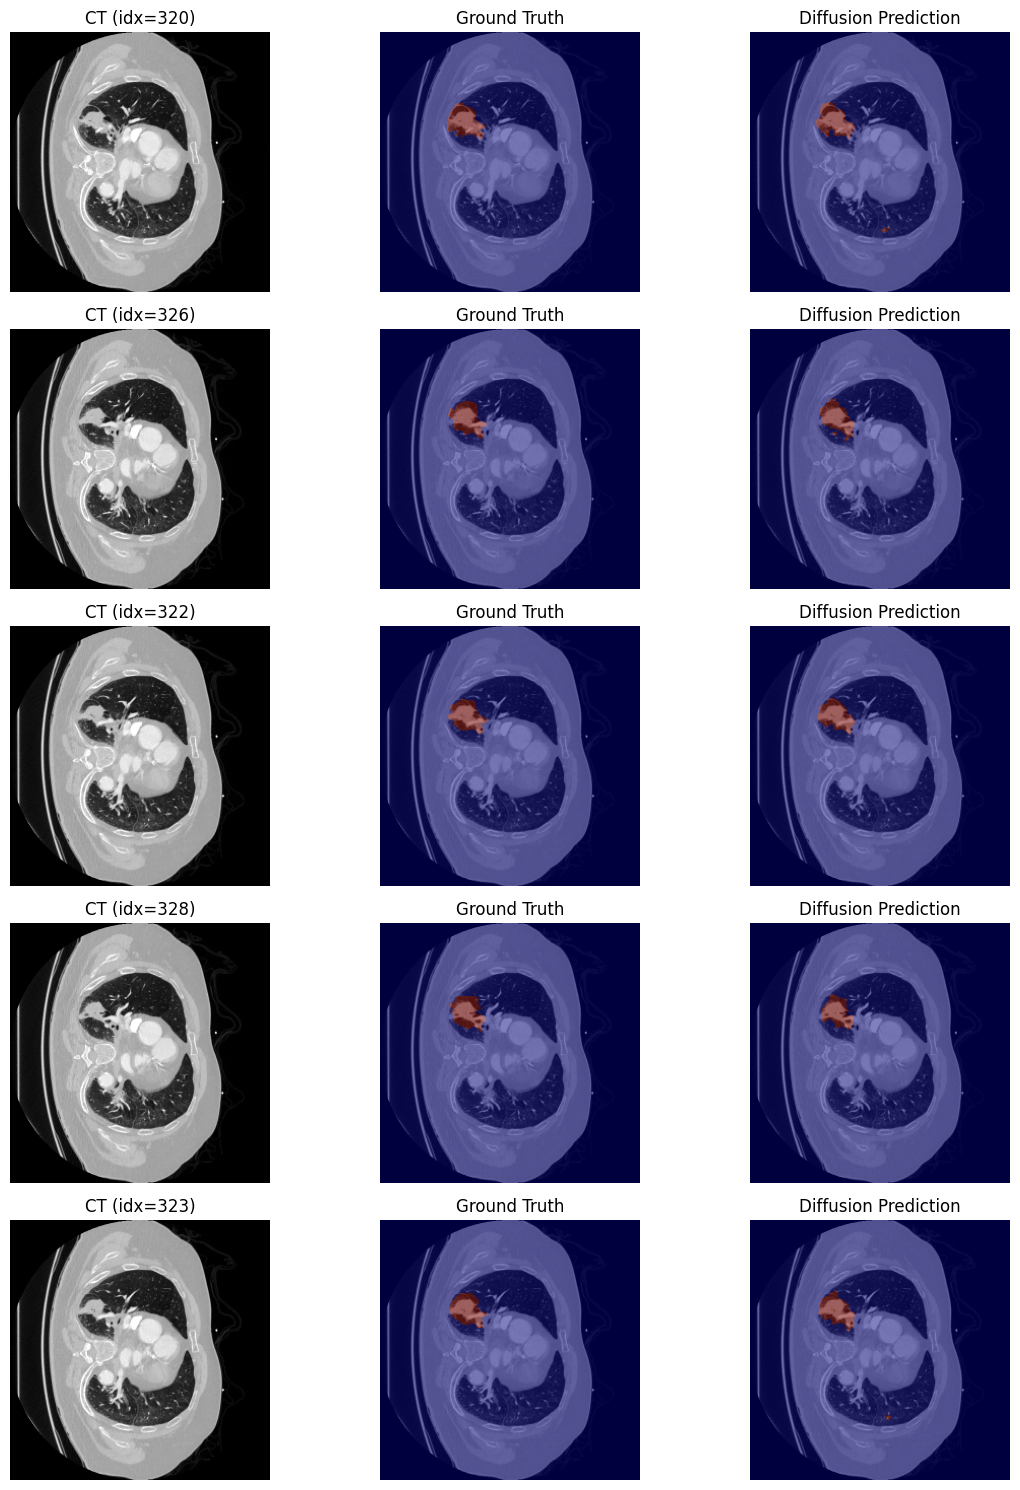

In [58]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load diffusion model
diffusion_model = DiffusionUNet().to(device)

state_dict = torch.load(
    "best_diffusion_unet_combined_loss.pth",
    map_location=device,
    weights_only=True
)

diffusion_model.load_state_dict(state_dict)
diffusion_model.eval()

print("Diffusion model loaded successfully")

# Get top 5 slices with largest tumors
slice_scores = []

for index in range(len(test_dataset)):
    _, mask_i = test_dataset[index]
    tumor_area = torch.sum(mask_i).item()
    slice_scores.append((tumor_area, index))

slice_scores.sort(reverse=True)
top5_indices = [idx for (_, idx) in slice_scores[:5]]

print("Top 5 indices:", top5_indices)

# Fixed inference timestep
inference_timestep = timesteps // 2

plt.figure(figsize=(12, 15))

for i, idx in enumerate(top5_indices):

    image, mask = test_dataset[idx]
    image_batch = image.unsqueeze(0).to(device)
    mask_batch = mask.unsqueeze(0).to(device)

    batch_size = image_batch.shape[0]

    t = torch.full(
        (batch_size,),
        inference_timestep,
        device=device,
        dtype=torch.long
    )

    with torch.no_grad():
        noisy_mask, _ = add_noise_to_mask(mask_batch, t)

        predicted_noise = diffusion_model(image_batch, noisy_mask, t)

        predicted_clean_mask_logits = reconstruct_clean_mask(
            noisy_mask,
            predicted_noise,
            t
        )

        predicted_clean_mask_logits = torch.clamp(
            predicted_clean_mask_logits,
            -6.0,
            6.0
        )

        probs = torch.sigmoid(predicted_clean_mask_logits)
        pred_mask = (probs > 0.5).float()

    image_np = image.squeeze().cpu().numpy()
    gt_mask_np = mask.squeeze().cpu().numpy()
    pred_mask_np = pred_mask.squeeze().cpu().numpy()

    # CT
    plt.subplot(5, 3, i * 3 + 1)
    plt.imshow(image_np, cmap="gray")
    plt.title(f"CT (idx={idx})")
    plt.axis("off")

    # Ground truth overlay
    plt.subplot(5, 3, i * 3 + 2)
    plt.imshow(image_np, cmap="gray")
    plt.imshow(gt_mask_np, alpha=0.5, cmap="jet")
    plt.title("Ground Truth")
    plt.axis("off")

    # Diffusion prediction overlay
    plt.subplot(5, 3, i * 3 + 3)
    plt.imshow(image_np, cmap="gray")
    plt.imshow(pred_mask_np, alpha=0.5, cmap="jet")
    plt.title("Diffusion Prediction")
    plt.axis("off")

plt.tight_layout()
plt.savefig("top5_diffusion_predictions.png", dpi=300, bbox_inches="tight")
plt.show()

Diffusion model loaded successfully
Top 5 indices: [320, 326, 322, 328, 323]


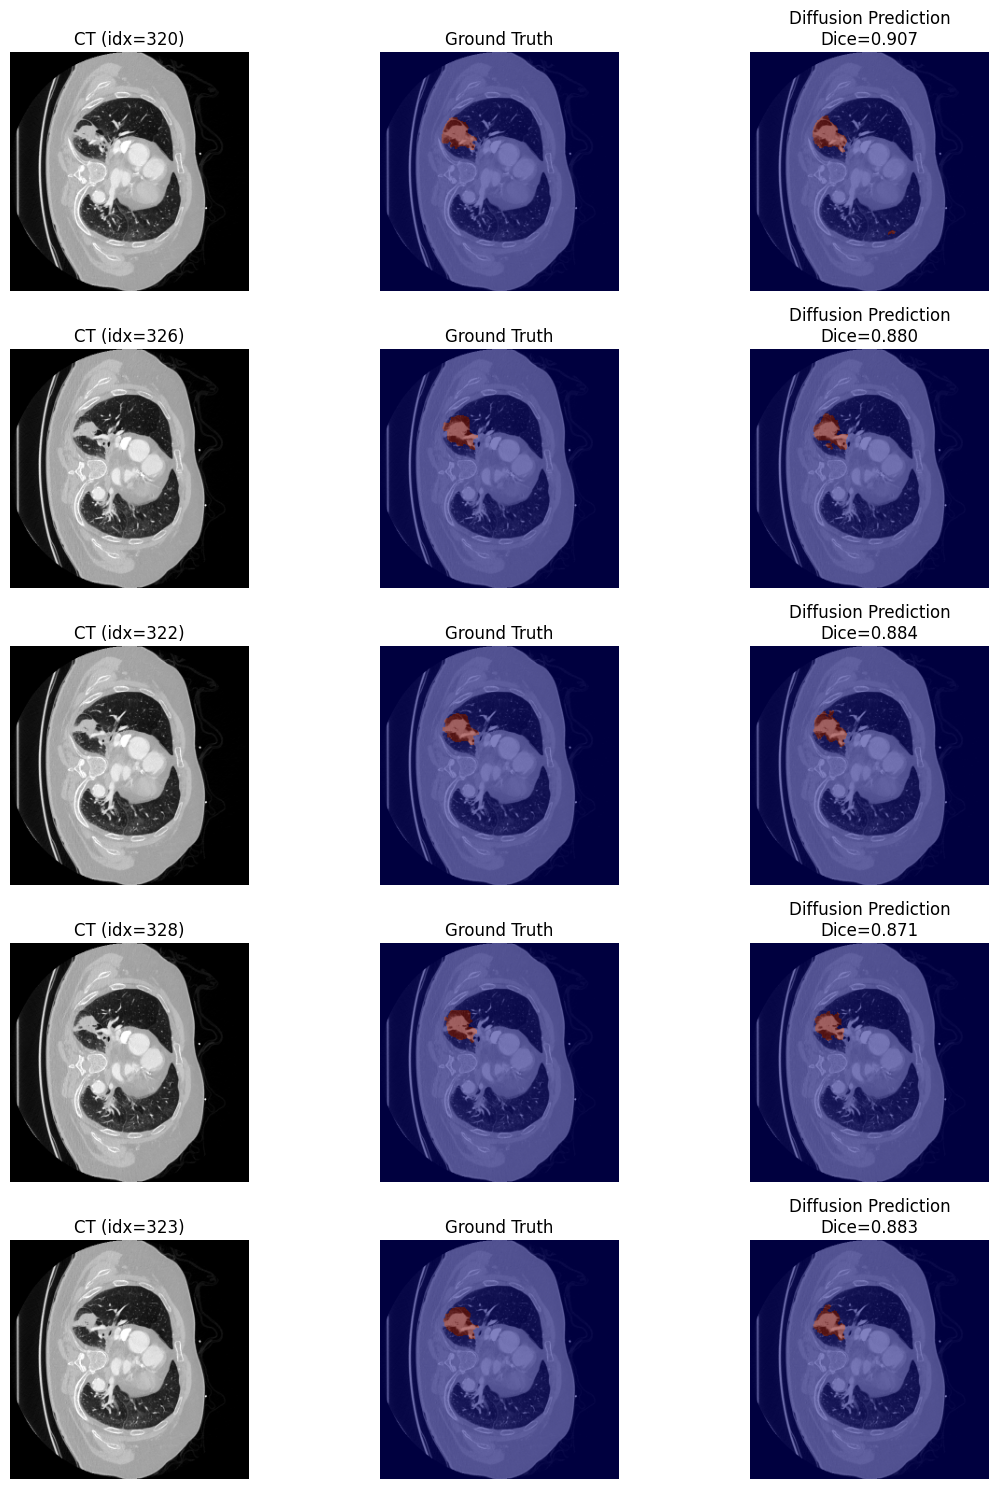

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dice score function
def dice_score(pred, target, smooth=1e-6):
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice

# Load diffusion model
diffusion_model = DiffusionUNet().to(device)

state_dict = torch.load(
    "best_diffusion_unet_combined_loss.pth",
    map_location=device,
    weights_only=True
)

diffusion_model.load_state_dict(state_dict)
diffusion_model.eval()

print("Diffusion model loaded successfully")




# Get top 5 slices with largest tumors
slice_scores = []

for index in range(len(test_dataset)):
    _, mask_i = test_dataset[index]
    tumor_area = torch.sum(mask_i).item()
    slice_scores.append((tumor_area, index))

slice_scores.sort(reverse=True)
top5_indices = [idx for (_, idx) in slice_scores[:5]]

print("Top 5 indices:", top5_indices)

# Fixed inference timestep
inference_timestep = timesteps // 2

plt.figure(figsize=(12, 15))

for i, idx in enumerate(top5_indices):

    image, mask = test_dataset[idx]

    image_batch = image.unsqueeze(0).to(device)
    mask_batch = mask.unsqueeze(0).to(device)

    batch_size = image_batch.shape[0]

    t = torch.full(
        (batch_size,),
        inference_timestep,
        device=device,
        dtype=torch.long
    )

    with torch.no_grad():
        noisy_mask, _ = add_noise_to_mask(mask_batch, t)

        predicted_noise = diffusion_model(image_batch, noisy_mask, t)

        predicted_clean_mask_logits = reconstruct_clean_mask(
            noisy_mask,
            predicted_noise,
            t
        )

        predicted_clean_mask_logits = torch.clamp(
            predicted_clean_mask_logits,
            -6.0,
            6.0
        )

        probs = torch.sigmoid(predicted_clean_mask_logits)
        pred_mask = (probs > 0.5).float()

        # Dice per slice
        dice = dice_score(pred_mask, mask_batch).item()

    image_np = image.squeeze().cpu().numpy()
    gt_mask_np = mask.squeeze().cpu().numpy()
    pred_mask_np = pred_mask.squeeze().cpu().numpy()

    # CT
    plt.subplot(5, 3, i * 3 + 1)
    plt.imshow(image_np, cmap="gray")
    plt.title(f"CT (idx={idx})")
    plt.axis("off")

    # Ground truth overlay
    plt.subplot(5, 3, i * 3 + 2)
    plt.imshow(image_np, cmap="gray")
    plt.imshow(gt_mask_np, alpha=0.5, cmap="jet")
    plt.title("Ground Truth")
    plt.axis("off")

    # Diffusion prediction overlay with Dice
    plt.subplot(5, 3, i * 3 + 3)
    plt.imshow(image_np, cmap="gray")
    plt.imshow(pred_mask_np, alpha=0.5, cmap="jet")
    plt.title(f"Diffusion Prediction\nDice={dice:.3f}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("top5_diffusion_predictions_with_dice.png", dpi=300, bbox_inches="tight")
plt.show()